In [1]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 8.0 MB/s eta 0:00:00


אנא העלי את קובץ הנתונים:


Saving disney_movies_total_gross.csv.csv to disney_movies_total_gross.csv (9).csv
Total films before cleaning: 579
Total films after removing missing genres: 562

--- Table 1: Summary Statistics ---
Number of films: 579
Known genre: 562
Missing genre: 17
Mean revenue: $121.70 million
Median revenue: $56.28 million
SD: $289.81 million
Max: $5228.95 million


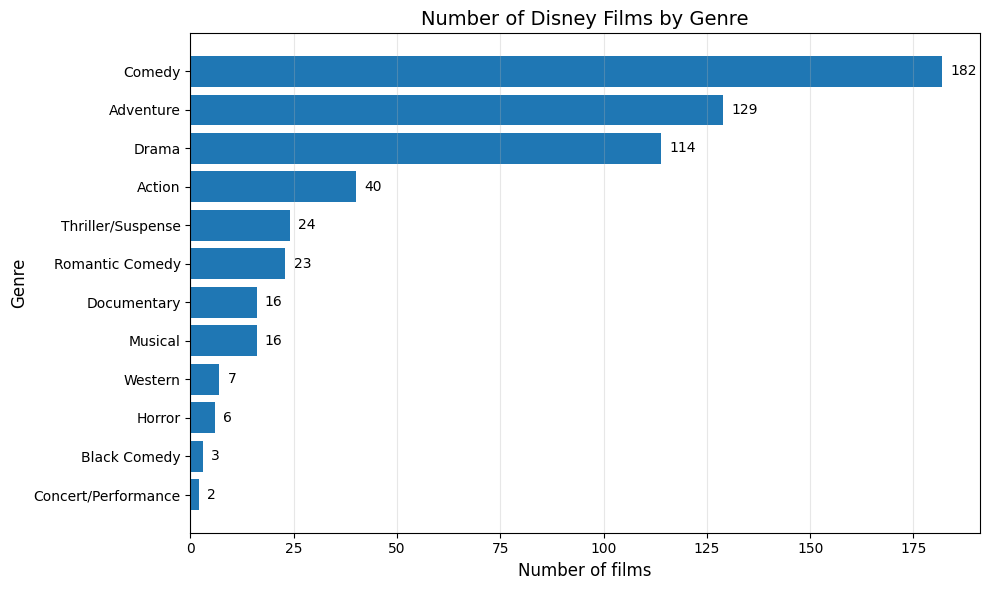


--- Table 2: Revenue by Genre ---
              genre   n   Mean  Median      SD    IQR
            Musical  16 603.60  103.17 1346.57 204.40
          Adventure 129 190.40  102.25  254.60 208.15
            Western   7  73.82   89.04   36.38  35.99
             Action  40 137.47   69.01  145.31 144.65
    Romantic Comedy  23  77.78   57.93   79.86  68.74
Concert/Performance   2  57.41   57.41   27.20  19.24
  Thriller/Suspense  24  89.65   51.80  112.12  83.36
       Black Comedy   3  52.24   51.58   24.19  24.18
             Comedy 182  84.67   51.20  122.65  84.14
              Drama 114  71.89   39.33  146.11  73.33
             Horror   6  23.41   18.59   13.93  11.36
        Documentary  16  12.72   12.34   11.34  17.67


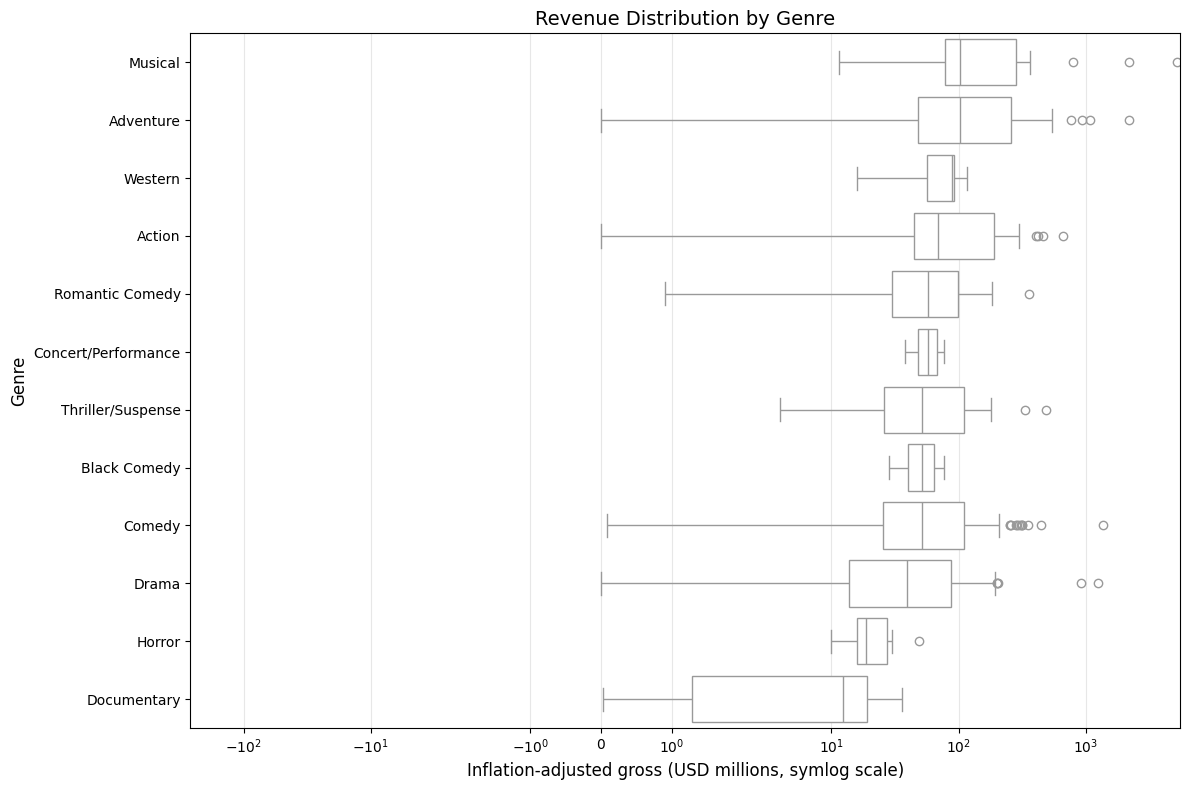

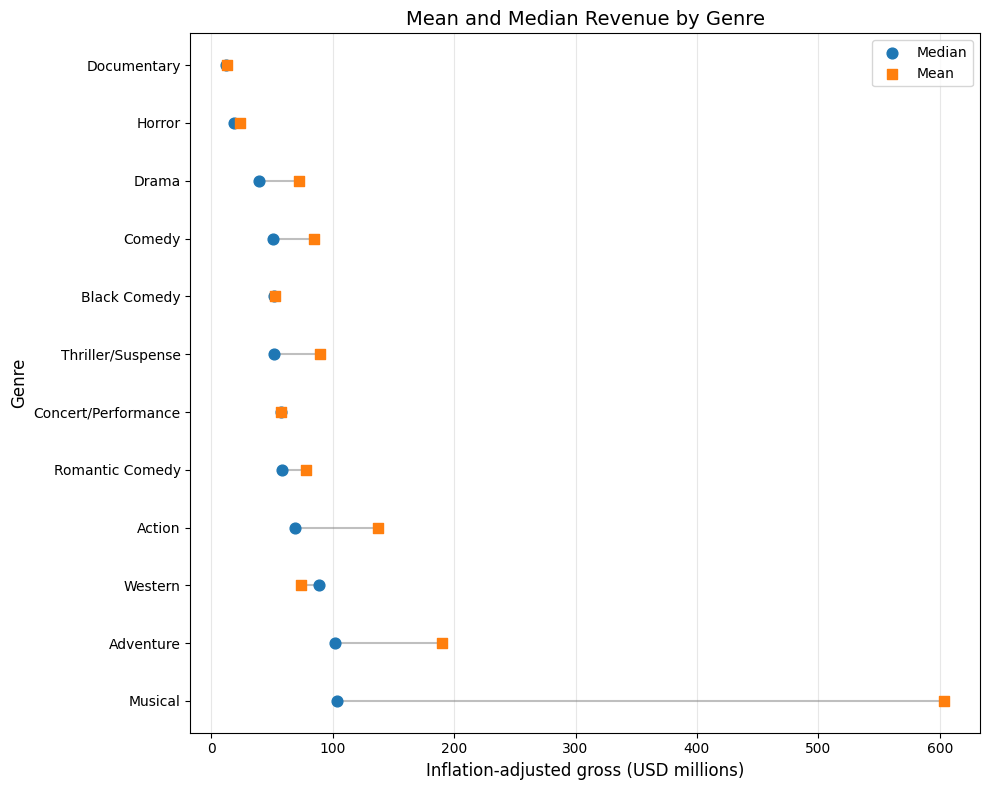


--- Table 3: Omnibus Tests ---
Classical ANOVA:
                sum_sq     df         F        PR(>F)
C(genre)  5.222554e+06   11.0  6.232648  1.017126e-09
Residual  4.189675e+07  550.0       NaN           NaN

Welch's ANOVA:
  Source  ddof1      ddof2          F         p_unc       np2
0  genre     11  24.394565  13.529442  8.016439e-08  0.110837

Kruskal-Wallis:
        Source  ddof1          H         p_unc
Kruskal  genre     11  88.918865  2.714436e-14

Brown-Forsythe Variance Test:
               W          pval  equal_var
levene  5.484651  2.462240e-08      False

--- Games-Howell Post-Hoc Comparisons ---
              A                B      diff    pval
14    Adventure      Documentary  177.6794  0.0000
31       Comedy      Documentary   71.9497  0.0000
16    Adventure           Horror  166.9836  0.0000
33       Comedy           Horror   61.2539  0.0000
4        Action      Documentary  124.7554  0.0002
15    Adventure            Drama  118.5044  0.0006
6        Action        

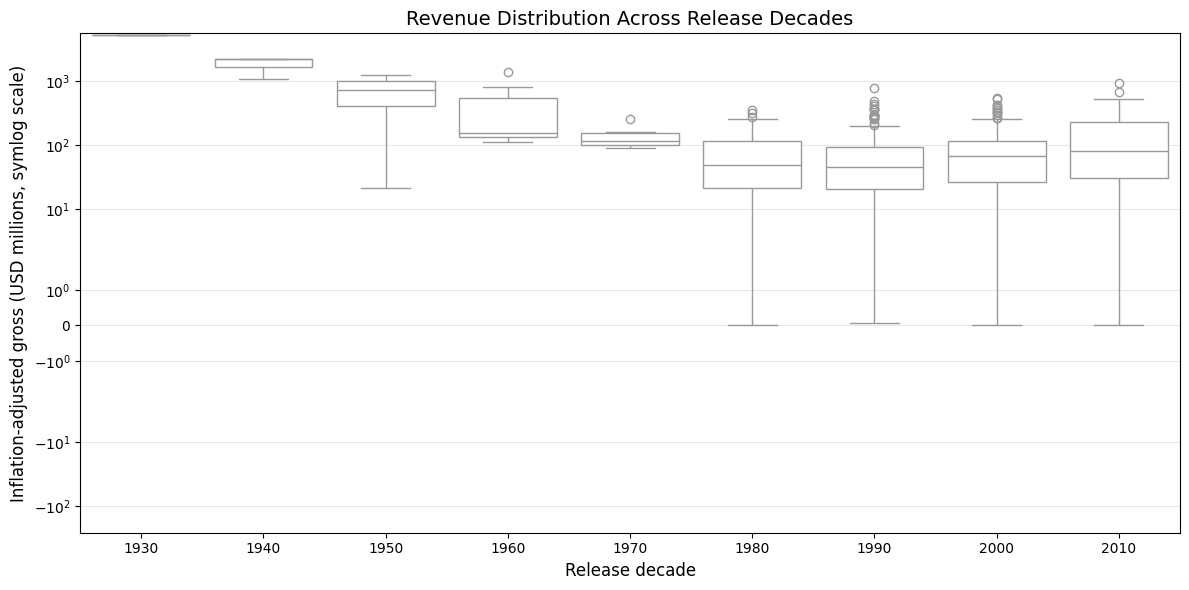

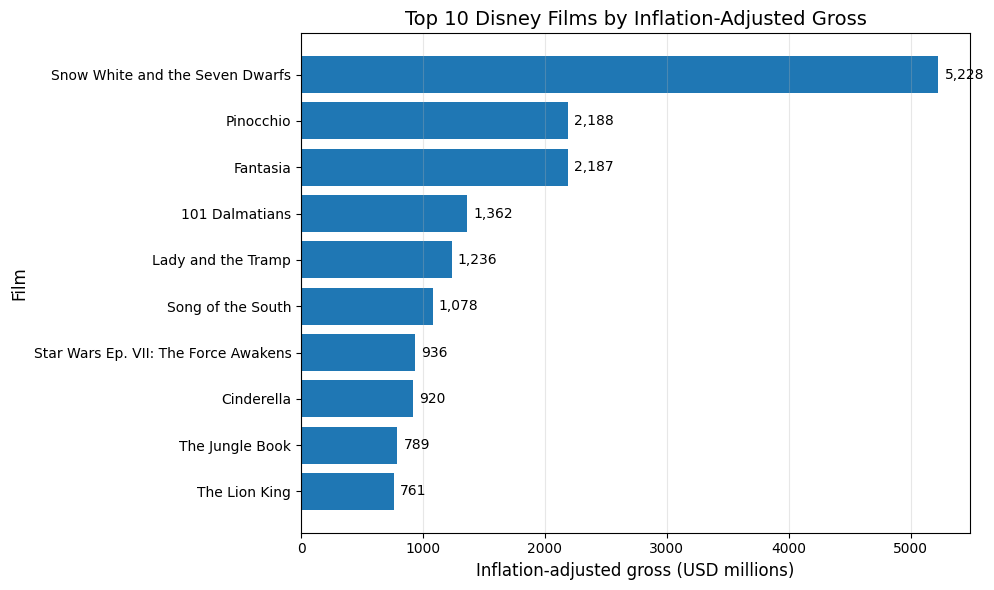


--- OLS Regression ---
R-squared: 0.165

--- Logistic Regression (Predicting Top Quartile) ---
Top-quartile prevalence: 25.1%
Cross-validated ROC AUC: 0.667
Balanced accuracy: 63.4%
Precision: 38.7%
Recall: 54.1%
F1 score: 44.5%


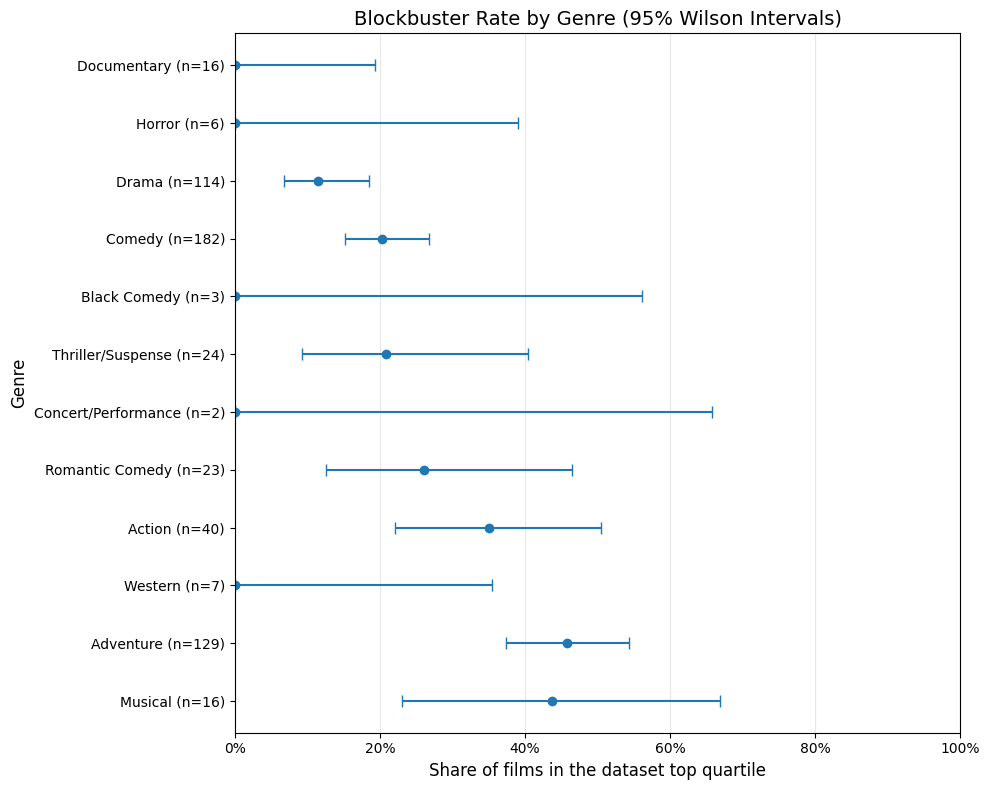

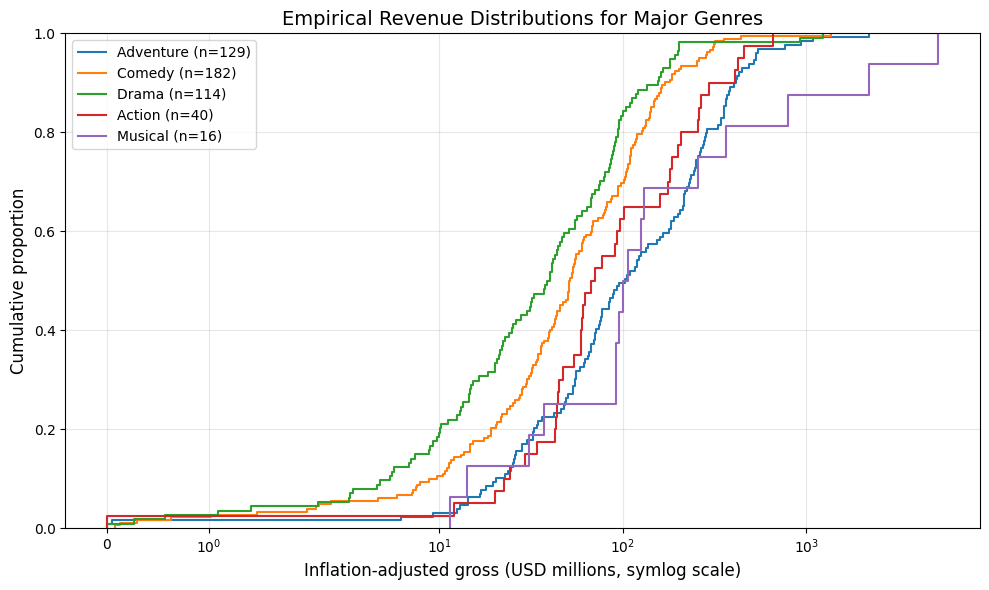

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pingouin as pg
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, make_scorer, precision_score, recall_score, f1_score

# ==========================================
# 0. Data Loading and Preprocessing
# ==========================================
# Make sure the CSV file is in the same folder as your code
from google.colab import files
print("אנא העלי את קובץ הנתונים:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
# Convert revenue columns to numeric (remove $ and commas)
def clean_currency(x):
    if isinstance(x, str):
        return float(x.replace('$', '').replace(',', ''))
    return x

df['total_gross'] = df['total_gross'].apply(clean_currency)
df['inflation_adjusted_gross'] = df['inflation_adjusted_gross'].apply(clean_currency)

# Convert revenue to millions for readability
df['inflation_adjusted_gross_millions'] = df['inflation_adjusted_gross'] / 1e6

# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'])

# Exclude missing genres ("Unknown" or NaN) as mentioned in the paper
df_main = df.dropna(subset=['genre']).copy()
df_main = df_main[df_main['genre'] != 'Unknown']

print(f"Total films before cleaning: {len(df)}")
print(f"Total films after removing missing genres: {len(df_main)}")

# ==========================================
# Table 1: Summary Statistics
# ==========================================
print("\n--- Table 1: Summary Statistics ---")
print(f"Number of films: {len(df)}")
print(f"Known genre: {len(df_main)}")
print(f"Missing genre: {len(df) - len(df_main)}")
print(f"Mean revenue: ${df_main['inflation_adjusted_gross_millions'].mean():.2f} million")
print(f"Median revenue: ${df_main['inflation_adjusted_gross_millions'].median():.2f} million")
print(f"SD: ${df_main['inflation_adjusted_gross_millions'].std():.2f} million")
print(f"Max: ${df_main['inflation_adjusted_gross_millions'].max():.2f} million")


# ==========================================
# Figure 1: Genre Distribution
# ==========================================
plt.figure(figsize=(10, 6))
genre_counts = df_main['genre'].value_counts().sort_values()
bars = plt.barh(genre_counts.index, genre_counts.values, color='tab:blue')
plt.xlabel('Number of films', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.title('Number of Disney Films by Genre', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Add text labels on the bars
for bar in bars:
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


# ==========================================
# Table 2: Descriptive Statistics by Genre
# ==========================================
print("\n--- Table 2: Revenue by Genre ---")
genre_stats = df_main.groupby('genre')['inflation_adjusted_gross_millions'].agg(
    n='count', Mean='mean', Median='median', SD='std').reset_index()
genre_stats['IQR'] = df_main.groupby('genre')['inflation_adjusted_gross_millions'].apply(stats.iqr).values
genre_stats = genre_stats.sort_values(by='Median', ascending=False)
print(genre_stats.round(2).to_string(index=False))


# ==========================================
# Figure 2: Boxplots of Revenue by Genre (Symlog Scale)
# ==========================================
plt.figure(figsize=(12, 8))
# Sort genres by median for the plot
sorted_genres = genre_stats['genre'].tolist()
sns.boxplot(data=df_main, x='inflation_adjusted_gross_millions', y='genre', order=sorted_genres, color='white', fliersize=6)
plt.xscale('symlog')
plt.xlabel('Inflation-adjusted gross (USD millions, symlog scale)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.title('Revenue Distribution by Genre', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# Figure 3: Mean vs Median by Genre
# ==========================================
plt.figure(figsize=(10, 8))
for i, genre in enumerate(sorted_genres):
    row = genre_stats[genre_stats['genre'] == genre]
    plt.plot([row['Median'].values[0], row['Mean'].values[0]], [i, i], color='grey', alpha=0.5)
    plt.scatter(row['Median'].values[0], i, color='tab:blue', s=60, zorder=3, label='Median' if i==0 else "")
    plt.scatter(row['Mean'].values[0], i, color='tab:orange', marker='s', s=60, zorder=3, label='Mean' if i==0 else "")

plt.yticks(range(len(sorted_genres)), sorted_genres)
plt.xlabel('Inflation-adjusted gross (USD millions)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.title('Mean and Median Revenue by Genre', fontsize=14)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# Table 3: Assumption Diagnostics and Omnibus Tests
# ==========================================
print("\n--- Table 3: Omnibus Tests ---")

# 1. Classical ANOVA (using statsmodels to avoid pingouin column name issues)
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('inflation_adjusted_gross_millions ~ C(genre)', data=df_main).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("Classical ANOVA:")
print(anova_table)

# 2. Welch's ANOVA
welch_res = pg.welch_anova(data=df_main, dv='inflation_adjusted_gross_millions', between='genre')
print("\nWelch's ANOVA:")
print(welch_res)

# 3. Kruskal-Wallis
kruskal_res = pg.kruskal(data=df_main, dv='inflation_adjusted_gross_millions', between='genre')
print("\nKruskal-Wallis:")
print(kruskal_res)

# 4. Brown-Forsythe test (Variance equality)
bf_res = pg.homoscedasticity(data=df_main, dv='inflation_adjusted_gross_millions', group='genre', method='levene')
print("\nBrown-Forsythe Variance Test:")
print(bf_res)


# ==========================================
# Table 4 & Appendix A: Games-Howell Post-Hoc
# ==========================================
print("\n--- Games-Howell Post-Hoc Comparisons ---")
gh_res = pg.pairwise_gameshowell(data=df_main, dv='inflation_adjusted_gross_millions', between='genre')
significant_gh = gh_res[gh_res['pval'] < 0.05].sort_values(by='pval')
print(significant_gh[['A', 'B', 'diff', 'pval']].round(4))


# ==========================================
# Figure 4: Revenue by Release Decade
# ==========================================
df_main['decade'] = (df_main['release_date'].dt.year // 10) * 10
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_main, x='decade', y='inflation_adjusted_gross_millions', color='white')
plt.yscale('symlog')
plt.xlabel('Release decade', fontsize=12)
plt.ylabel('Inflation-adjusted gross (USD millions, symlog scale)', fontsize=12)
plt.title('Revenue Distribution Across Release Decades', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# Figure 5: Top 10 Highest Grossing Films
# ==========================================
top10 = df_main.nlargest(10, 'inflation_adjusted_gross_millions').sort_values('inflation_adjusted_gross_millions')
plt.figure(figsize=(10, 6))
bars = plt.barh(top10['movie_title'], top10['inflation_adjusted_gross_millions'], color='tab:blue')
plt.xlabel('Inflation-adjusted gross (USD millions)', fontsize=12)
plt.ylabel('Film', fontsize=12)
plt.title('Top 10 Disney Films by Inflation-Adjusted Gross', fontsize=14)
plt.grid(axis='x', alpha=0.3)

for bar in bars:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f"{int(bar.get_width()):,}", va='center', fontsize=10)

plt.tight_layout()
plt.show()


# ==========================================
# OLS Regression (log-transformed revenue)
# ==========================================
print("\n--- OLS Regression ---")
df_main['log_revenue'] = np.log1p(df_main['inflation_adjusted_gross_millions'])
# Dummy code genres, dropping one as reference
X = pd.get_dummies(df_main['genre'], drop_first=True).astype(float)
X = sm.add_constant(X)
y = df_main['log_revenue']
ols_model = sm.OLS(y, X).fit(cov_type='HC3') # Robust OLS
print(f"R-squared: {ols_model.rsquared:.3f}")


# ==========================================
# Table 5 & Classification (Logistic Regression)
# ==========================================
print("\n--- Logistic Regression (Predicting Top Quartile) ---")
threshold = df_main['inflation_adjusted_gross_millions'].quantile(0.75)
df_main['is_blockbuster'] = (df_main['inflation_adjusted_gross_millions'] >= threshold).astype(int)

X_clf = pd.get_dummies(df_main['genre']).astype(float)
y_clf = df_main['is_blockbuster']

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
scoring = {'roc_auc': 'roc_auc', 'accuracy': 'accuracy',
           'balanced_accuracy': 'balanced_accuracy',
           'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

cv_results = cross_validate(log_reg, X_clf, y_clf, cv=5, scoring=scoring)

print(f"Top-quartile prevalence: {(y_clf.mean() * 100):.1f}%")
print(f"Cross-validated ROC AUC: {cv_results['test_roc_auc'].mean():.3f}")
print(f"Balanced accuracy: {cv_results['test_balanced_accuracy'].mean():.1%}")
print(f"Precision: {cv_results['test_precision'].mean():.1%}")
print(f"Recall: {cv_results['test_recall'].mean():.1%}")
print(f"F1 score: {cv_results['test_f1'].mean():.1%}")


# ==========================================
# Figure 6: Blockbuster Rate by Genre
# ==========================================
plt.figure(figsize=(10, 8))
rates = []
ci_low = []
ci_high = []
n_vals = []

for g in sorted_genres:
    subset = df_main[df_main['genre'] == g]['is_blockbuster']
    successes = int(subset.sum())
    n = int(len(subset))
    rate = float(successes / n) if n > 0 else 0.0
    low, high = proportion_confint(successes, n, method='wilson')

    rates.append(rate)
    # Ensure errors are strictly non-negative to prevent ValueError
    ci_low.append(max(0.0, rate - low))
    ci_high.append(max(0.0, high - rate))
    n_vals.append(n)

y_pos = np.arange(len(sorted_genres))

for i in range(len(sorted_genres)):
    plt.errorbar(rates[i], y_pos[i],
                 xerr=np.array([[ci_low[i]], [ci_high[i]]]),
                 fmt='o', color='tab:blue', capsize=4)

plt.yticks(y_pos, [f"{g} (n={n})" for g, n in zip(sorted_genres, n_vals)])
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x*100)}%'))
plt.xlabel('Share of films in the dataset top quartile', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.title('Blockbuster Rate by Genre (95% Wilson Intervals)', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# Figure 7: Empirical Revenue Distributions (Top 5 Genres)
# ==========================================
top_5_genres = ['Adventure', 'Comedy', 'Drama', 'Action', 'Musical']
plt.figure(figsize=(10, 6))

for genre in top_5_genres:
    data = df_main[df_main['genre'] == genre]['inflation_adjusted_gross_millions']
    n = len(data)
    sns.ecdfplot(data, label=f"{genre} (n={n})")

plt.xscale('symlog')
plt.xlabel('Inflation-adjusted gross (USD millions, symlog scale)', fontsize=12)
plt.ylabel('Cumulative proportion', fontsize=12)
plt.title('Empirical Revenue Distributions for Major Genres', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()